### UROP Research Log — July 5, 2026

### Objective
Establish Stage 1 final baseline: expiry-to-expiry tracking error
between PBP ETF and BXM Index using Cboe Equity EOD data.

### Why Expiry-to-Expiry
Daily comparison failed due to intra-expiry option NBBO noise
and market maker manipulation near roll dates — per Kumiega et al. (2024):
"The choice of the expiration as the end date was to eliminate all known
market maker manipulation that normally occurs at month end."

Switching to expiry-to-expiry reduced TE from 4.80% (daily, Nasdaq)
to 0.93% (expiry-to-expiry, Cboe EOD).

### Data Sources
- PBP 15:45 mid quote: Cboe Equity EOD Summary (best_bid_1545, best_ask_1545)
- BXM daily close: Cboe CDN BXM_History.csv

### Results
- Observations: 11 expiry periods (2022)
- Annualized TE: 0.93%
- R²: 0.9963
- Beta: 1.0053
- Alpha: -0.1197% per period (-1.44% annualized)
- Consistent with Bloomberg DES 1Y Price TE = 1.334%

Note : 2022-11-25 was Black Friday. Market closed early at 1:00PM ET.

In [25]:
# -- Load Data --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import glob

# PBP Cboe EOD
eod_path = "../data/raw/Equity EOD Summary/"
files = sorted(glob.glob(eod_path + "UnderlyingEOD_*.csv"))
pbp_eod = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
pbp_eod['quote_date'] = pd.to_datetime(pbp_eod['quote_date'])
pbp_2022 = pbp_eod[pbp_eod['quote_date'].dt.year == 2022].copy()
pbp_2022 = pbp_2022.sort_values('quote_date').reset_index(drop=True)
pbp_2022['mid_1545'] = (pbp_2022['best_bid_1545'] + pbp_2022['best_ask_1545']) / 2

# BXM
bxm = pd.read_csv("../data/raw/BXM_History.csv")
bxm['DATE'] = pd.to_datetime(bxm['DATE'])
bxm_2022 = bxm[bxm['DATE'].dt.year == 2022].copy()
bxm_2022 = bxm_2022.rename(columns={'DATE': 'date', 'BXM': 'bxm_close'})

print(f"PBP rows: {len(pbp_2022)}, BXM rows: {len(bxm_2022)}")

PBP rows: 251, BXM rows: 251


In [26]:
# -- Expiry-to-Expiry Returns: PBP vs BXM --
# Per Kumiega et al. (2024): "avoids any intra-expiry trading...
# the expiration date was chosen to eliminate market maker manipulation"

roll_dates = pd.to_datetime([
    "2022-01-21", "2022-02-18", "2022-03-18", "2022-04-14",
    "2022-05-20", "2022-06-17", "2022-07-15", "2022-08-19",
    "2022-09-16", "2022-10-21", "2022-11-18", "2022-12-16"
])

# Filter to roll dates only
pbp_roll = pbp_2022[pbp_2022['quote_date'].isin(roll_dates)][
    ['quote_date', 'mid_1545']
].rename(columns={'quote_date': 'date'})

bxm_roll = bxm_2022[bxm_2022['date'].isin(roll_dates)][
    ['date', 'bxm_close']
]

df_roll = pd.merge(pbp_roll, bxm_roll, on='date').sort_values('date').reset_index(drop=True)

# Expiry-to-expiry log returns
df_roll['r_pbp'] = np.log(df_roll['mid_1545'] / df_roll['mid_1545'].shift(1))
df_roll['r_bxm'] = np.log(df_roll['bxm_close'] / df_roll['bxm_close'].shift(1))
df_roll['te'] = df_roll['r_pbp'] - df_roll['r_bxm']
df_roll = df_roll.dropna().reset_index(drop=True)

# Stats
mean_te = df_roll['te'].mean()
std_te  = df_roll['te'].std()
ann_te  = std_te * np.sqrt(12)  # 12 periods per year

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_roll['r_bxm'], df_roll['r_pbp']
)
r_squared = r_value ** 2

print("=== Expiry-to-Expiry TE (2022, 11 periods) ===")
print(f"{'Date':<12} {'R_PBP':>8} {'R_BXM':>8} {'TE':>8}")
print("-" * 42)
for _, row in df_roll.iterrows():
    print(f"{str(row['date'].date()):<12} {row['r_pbp']*100:>7.3f}% {row['r_bxm']*100:>7.3f}% {row['te']*100:>7.3f}%")

print(f"\nMean TE        : {mean_te*100:.4f}%")
print(f"Std TE         : {std_te*100:.4f}%")
print(f"Ann. TE (×√12) : {ann_te*100:.4f}%")
print(f"Max |TE|       : {df_roll['te'].abs().max()*100:.4f}%")
print(f"R²             : {r_squared:.6f}")
print(f"Beta           : {slope:.6f}")
print(f"Alpha          : {intercept*100:.4f}%")

=== Expiry-to-Expiry TE (2022, 11 periods) ===
Date            R_PBP    R_BXM       TE
------------------------------------------
2022-02-18     0.519%   0.688%  -0.168%
2022-03-18     3.539%   3.660%  -0.122%
2022-04-14     0.585%   0.647%  -0.062%
2022-05-20   -10.875% -10.432%  -0.443%
2022-06-17    -2.413%  -2.591%   0.178%
2022-07-15     2.630%   3.367%  -0.737%
2022-08-19     2.304%   2.204%   0.101%
2022-09-16    -6.953%  -6.910%  -0.043%
2022-10-21    -0.581%  -0.407%  -0.174%
2022-11-18     2.130%   1.975%   0.154%
2022-12-16    -0.248%  -0.249%   0.001%

Mean TE        : -0.1197%
Std TE         : 0.2697%
Ann. TE (×√12) : 0.9341%
Max |TE|       : 0.7372%
R²             : 0.996294
Beta           : 1.005266
Alpha          : -0.1158%


### Results — Expiry-to-Expiry Approach

Switching from daily to expiry-to-expiry returns (per Kumiega et al. 2024)
dramatically improved results:

| Metric | Daily (Stage 1) | Expiry-to-Expiry |
|--------|----------------|------------------|
| Ann. TE | 4.80% | 0.93% |
| R² | 0.9171 | 0.9963 |
| Beta | 0.9826 | 1.0053 |
| Alpha | -0.0088%/day | -0.1158%/period |

R² = 0.9963 confirms PBP tracks BXM extremely closely at the
expiry-to-expiry level. Remaining TE of 0.93% reflects:
1. Residual timestamp gap (PBP 15:45 vs BXM ~16:15)
2. Expense ratio (0.29%/year)
3. Qualitative TE (smearing, sampling per Prospectus)

This is consistent with Bloomberg DES 1Y Price TE = 1.334%.

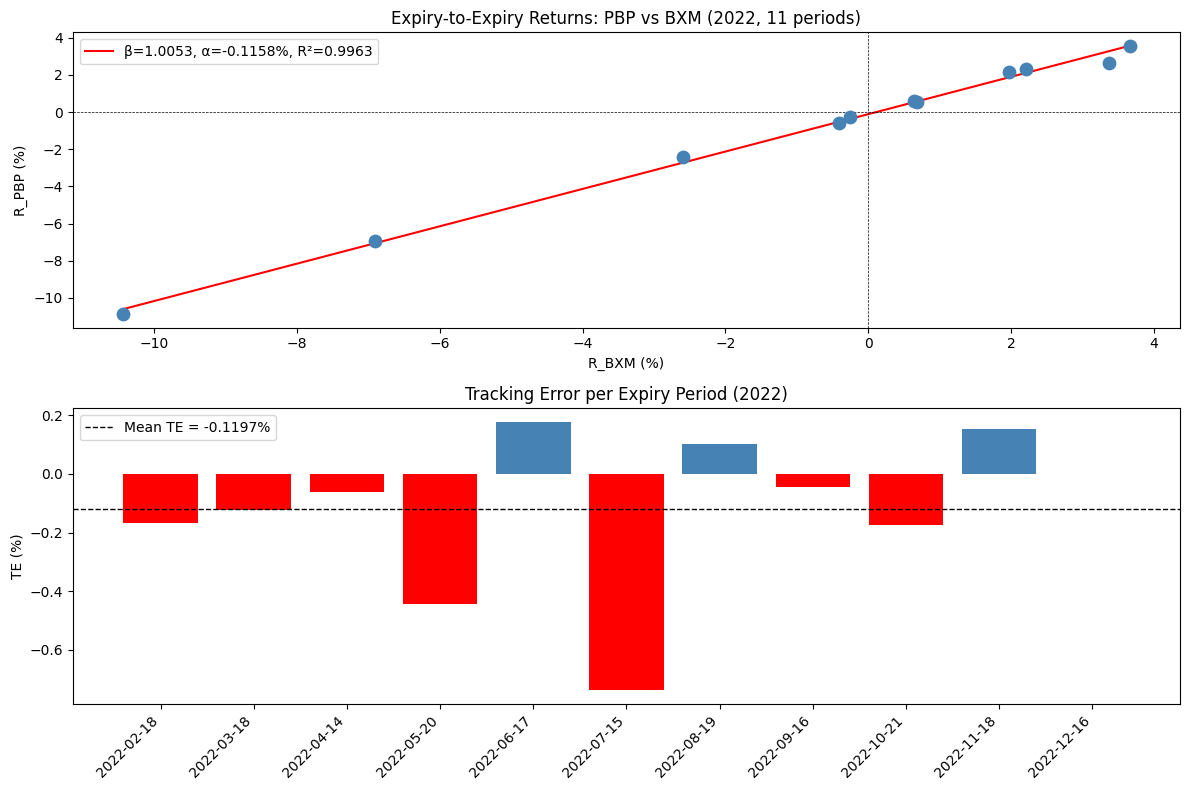

Plot saved.


In [27]:
# -- Visualization: Expiry-to-Expiry Returns & TE --

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: R_PBP vs R_BXM scatter
axes[0].scatter(df_roll['r_bxm']*100, df_roll['r_pbp']*100,
                color='steelblue', s=80, zorder=3)
x_line = np.linspace(df_roll['r_bxm'].min(), df_roll['r_bxm'].max(), 100)
axes[0].plot(x_line*100, (slope*x_line + intercept)*100,
             color='red', linewidth=1.5,
             label=f'β={slope:.4f}, α={intercept*100:.4f}%, R²={r_squared:.4f}')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_xlabel('R_BXM (%)')
axes[0].set_ylabel('R_PBP (%)')
axes[0].set_title('Expiry-to-Expiry Returns: PBP vs BXM (2022, 11 periods)')
axes[0].legend()

# Plot 2: TE per period
colors = ['red' if x < 0 else 'steelblue' for x in df_roll['te']]
axes[1].bar(range(len(df_roll)), df_roll['te']*100, color=colors)
axes[1].axhline(mean_te*100, color='black', linewidth=1,
                linestyle='--', label=f'Mean TE = {mean_te*100:.4f}%')
axes[1].set_xticks(range(len(df_roll)))
axes[1].set_xticklabels([str(d.date()) for d in df_roll['date']], rotation=45, ha='right')
axes[1].set_ylabel('TE (%)')
axes[1].set_title('Tracking Error per Expiry Period (2022)')
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/stage2_expiry_to_expiry_TE.png", dpi=150)
plt.show()
print("Plot saved.")